# Laboratorio 7 — Spark MLlib
## ENEIC 2025–2026: perfiles de trabajadores asalariados y predicción del salario mensual

**Universidad del Valle de Guatemala — CC3084 Data Science — Semestre II 2026**

**Integrantes:**
- Daniel Oswaldo Juárez Herrera
- Humberto Alexander de la Cruz
- Nicolle Alexandra Gordillo


## 0. Configuración del entorno

### 0.1. Verificación de versiones

In [1]:
import os
import pyspark

print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("PySpark:", pyspark.__version__)

JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
PySpark: 3.5.1


### 0.2. Sesión de Spark

In [2]:
import sys
!{sys.executable} -m pip install openpyxl
from pyspark.sql import SparkSession
from pyspark.sql import functions as f
from pyspark.sql import types as T

spark = (
    SparkSession.builder
    .appName("Lab7_ENEIC_SparkML")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "16")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("Spark:", spark.version)
print("Java :", spark.sparkContext._jvm.java.lang.System.getProperty("java.version"))

Defaulting to user installation because normal site-packages is not writeable


/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 23:04:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.1
Java : 17.0.20.1


### 0.3. Parámetros del laboratorio

Aquí se define todo lo que depende del entorno: rutas de los archivos, nombres de columnas y
diccionarios de códigos. Si el notebook se ejecuta en otra máquina, basta con cambiar `DATA_DIR`
y los nombres de archivo de `ARCHIVOS`.

**Sobre `FACTOR`:** es el factor de expansión del diseño muestral. En un análisis poblacional se
usaría como peso para que cada registro represente a la cantidad de personas que le corresponde en
la población (por ejemplo, con `sum(FACTOR)` en lugar de `count()`, o con medias ponderadas). Como
el enunciado pide métricas no ponderadas, aquí solo se conserva para trazabilidad.

In [3]:
from pathlib import Path

# ==== RUTAS =================================================================
# Carpeta donde están los .xlsx de la ENEIC (ajustar según el entorno)
DATA_DIR = Path("/opt/app/working_dir/eneic")
OUT_DIR  = Path("/opt/app/working_dir/lab7_out")   # parquet y modelos generados
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ==== ARCHIVOS ==============================================================
# periodo_archivo, anio_archivo, trimestre_calendario se asignan por ARCHIVO DE
# PROCEDENCIA, no por la columna TRIMESTRE (que viene corrida: 2,3,4,5,6).
ARCHIVOS = [
    # (nombre de archivo, periodo_archivo, anio_archivo, trimestre_calendario, uso)
    ("Personas_ENEIC_T1_2025.xlsx",                  "2025T1", 2025, 1, "train"),
    ("Personas-ENEIC-T2-2025.xlsx",                  "2025T2", 2025, 2, "train"),
    ("Base-de-datos-Personas-ENEIC-III-2025.xlsx",   "2025T3", 2025, 3, "train"),
    ("Base-de-datos-Personas-ENEIC-IV-2025.xlsx",    "2025T4", 2025, 4, "validacion"),
    ("Base-de-datos-Personas-ENEIC-I-2026.xlsx",     "2026T1", 2026, 1, "test"),
]

# ==== COLUMNAS ==============================================================
COLS_NUMERICAS = {
    "P05D01":  "salario_mensual",
    "P02A03":  "edad",
    "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses",
    "P05H01A": "horas_semanales",
    "FACTOR":  "FACTOR",
}
COLS_CATEGORICAS = {
    "P03A03A": "nivel_educativo_cod",
    "P05C16":  "categoria_ocupacional_cod",
    "DOMINIO": "dominio_cod",
    "OCUPADOS": "ocupado",
}
COLS_AUDITORIA = ["NUM_HOGAR", "NUM_PERSONA", "ANIO", "TRIMESTRE"]

COLS_ORIGINALES = list(COLS_NUMERICAS) + list(COLS_CATEGORICAS) + COLS_AUDITORIA

# ==== DICCIONARIOS DE CÓDIGOS ==============================================
# IMPORTANTE: verificar contra el diccionario de datos que acompaña a cada base.
# La celda 1.2 imprime los códigos realmente observados para completar/corregir.
MAPA_CATEGORIA_OCUPACIONAL = {
    "1": "Empleado de gobierno",
    "2": "Empleado de empresa privada",
    "3": "Jornalero o peon",
    "4": "Servicio domestico",
}
# Codigos observados en los archivos: 0,1,2,3,4,5,6,7 (y nulos)
MAPA_NIVEL_EDUCATIVO = {
    "0": "Ninguno",          # OJO: 0 = "ninguno", NO es un faltante
    "1": "Preprimaria",
    "2": "Primaria",
    "3": "Basicos",
    "4": "Diversificado",
    "5": "Superior universitario",
    "6": "Maestria",
    "7": "Doctorado",
}
# Codigos observados: 1, 2, 3
MAPA_DOMINIO = {
    "1": "Urbano metropolitano",
    "2": "Resto urbano",
    "3": "Rural nacional",
}
ETIQUETA_DESCONOCIDO = "DESCONOCIDO"

SEED = 42

---
## 1. Carga, armonización y calidad de datos (5 pts)

### 1.1. Lectura de los archivos de Excel

Spark no trae un lector nativo de Excel, así que cada archivo se lee **individualmente** con pandas
(para controlar la memoria), se le seleccionan únicamente las columnas requeridas, se homologan sus
tipos y se convierte a un DataFrame de Spark con un **esquema explícito**.

La lectura se hace **en streaming** con `openpyxl` en modo `read_only`, tomando fila por fila
únicamente las columnas requeridas. Esto es mucho más liviano que `pd.read_excel()`, que cargaría en
memoria las 270 columnas completas de cada archivo.

Puntos clave de la armonización:
- Los códigos llegan **mezclados**: en unos archivos como texto (`"2"`) y en otros como número
  entero (`2`). `limpiar_codigo()` los normaliza todos a texto antes de unir.
- `limpiar_codigo()` normaliza los códigos: quita espacios y convierte `"2.0"` → `"2"`.
- Las variables numéricas se convierten con `errors="coerce"`, de modo que un valor no numérico se
  vuelve nulo en lugar de romper la carga (esos casos se contabilizan en el filtrado).
- `periodo_archivo`, `anio_archivo`, `trimestre_calendario` y `archivo_origen` se asignan según el
  archivo de procedencia; la columna original `TRIMESTRE` se conserva sin modificar.

In [4]:
import re
import math
import time
import pandas as pd
import numpy as np
from openpyxl import load_workbook

def limpiar_codigo(valor):
    """Normaliza un codigo categorico: 2 -> '2', '2.0' -> '2', ' 3 ' -> '3', vacio -> None."""
    if valor is None:
        return None
    s = str(valor).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return None
    if re.fullmatch(r"-?\d+\.0+", s):
        s = s.split(".")[0]
    return s

def a_numero(valor):
    """Convierte a float; lo no numerico o no finito queda como None (no se imputa)."""
    s = limpiar_codigo(valor)
    if s is None:
        return None
    try:
        x = float(s)
    except ValueError:
        return None
    return x if math.isfinite(x) else None

ESQUEMA = T.StructType(
    [T.StructField(nombre, T.DoubleType(), True) for nombre in COLS_NUMERICAS.values()] +
    [T.StructField(nombre, T.StringType(), True) for nombre in COLS_CATEGORICAS.values()] +
    [T.StructField(c, T.StringType(), True) for c in COLS_AUDITORIA] +
    [
        T.StructField("periodo_archivo", T.StringType(), True),
        T.StructField("anio_archivo", T.IntegerType(), True),
        T.StructField("trimestre_calendario", T.IntegerType(), True),
        T.StructField("archivo_origen", T.StringType(), True),
    ]
)

def cargar_archivo(nombre_archivo, periodo, anio, trimestre_cal):
    """Lee un .xlsx de la ENEIC en streaming y devuelve un DataFrame de Spark homologado."""
    ruta = DATA_DIR / nombre_archivo
    libro = load_workbook(ruta, read_only=True, data_only=True)
    hoja = libro[libro.sheetnames[0]]
    filas_excel = hoja.iter_rows(values_only=True)

    encabezado = [str(h).strip().upper() if h is not None else "" for h in next(filas_excel)]
    faltantes = [c for c in COLS_ORIGINALES if c not in encabezado]
    if faltantes:
        libro.close()
        raise KeyError(f"{nombre_archivo}: faltan columnas {faltantes}")
    indices = [encabezado.index(c) for c in COLS_ORIGINALES]

    filas = []
    for fila in filas_excel:
        registro = [
            a_numero(fila[i]) if col in COLS_NUMERICAS else limpiar_codigo(fila[i])
            for col, i in zip(COLS_ORIGINALES, indices)
        ]
        registro += [periodo, anio, trimestre_cal, nombre_archivo]
        filas.append(tuple(registro))
    libro.close()

    return spark.createDataFrame(filas, schema=ESQUEMA)

# La lectura de los 5 archivos toma varios minutos (son ~50,000 filas x 270 columnas c/u)
dfs = {}
for nombre, periodo, anio, trim, uso in ARCHIVOS:
    inicio = time.time()
    dfs[periodo] = cargar_archivo(nombre, periodo, anio, trim).persist()
    n = dfs[periodo].count()
    print(f"{periodo} ({uso:10s}): {n:,} registros | {time.time() - inicio:.0f} s | {nombre}")

2025T1 (train     ): 51,588 registros | 61 s | Personas_ENEIC_T1_2025.xlsx
2025T2 (train     ): 51,167 registros | 23 s | Personas-ENEIC-T2-2025.xlsx
2025T3 (train     ): 51,583 registros | 64 s | Base-de-datos-Personas-ENEIC-III-2025.xlsx
2025T4 (validacion): 49,338 registros | 62 s | Base-de-datos-Personas-ENEIC-IV-2025.xlsx
2026T1 (test      ): 49,843 registros | 59 s | Base-de-datos-Personas-ENEIC-I-2026.xlsx


### 1.2. Unión de los archivos de 2025 con `unionByName`

Los cuatro trimestres de 2025 se apilan con `unionByName`, que hace la correspondencia **por nombre
de columna** y no por posición.

Antes de mapear los códigos a etiquetas, se imprimen los valores realmente observados en cada
variable categórica. Esto sirve para validar los diccionarios definidos en la sección 0.3 y para
detectar códigos no reconocidos.

In [5]:
crudo_2025 = (
    dfs["2025T1"]
    .unionByName(dfs["2025T2"])
    .unionByName(dfs["2025T3"])
    .unionByName(dfs["2025T4"])
).persist()

crudo_2026 = dfs["2026T1"].persist()

print("Registros crudos 2025:", f"{crudo_2025.count():,}")
print("Registros crudos 2026:", f"{crudo_2026.count():,}")

print("\n--- Esquema de las columnas seleccionadas ---")
crudo_2025.printSchema()

print("--- Cinco registros ---")
crudo_2025.show(5, truncate=False)

print("--- Codigos observados por variable categorica (2025) ---")
for col in ["nivel_educativo_cod", "categoria_ocupacional_cod", "dominio_cod", "ocupado"]:
    valores = sorted(
        [r[0] for r in crudo_2025.select(col).distinct().collect() if r[0] is not None]
    )
    print(f"{col:28s}: {valores}")

print("\n--- TRIMESTRE original por archivo (auditoria de la fuente) ---")
(crudo_2025.unionByName(crudo_2026)
    .groupBy("periodo_archivo", "trimestre_calendario", "TRIMESTRE")
    .count()
    .orderBy("periodo_archivo", "TRIMESTRE")
    .show(20, truncate=False))

Registros crudos 2025: 203,676
Registros crudos 2026: 49,843

--- Esquema de las columnas seleccionadas ---
root
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- nivel_educativo_cod: string (nullable = true)
 |-- categoria_ocupacional_cod: string (nullable = true)
 |-- dominio_cod: string (nullable = true)
 |-- ocupado: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- ANIO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- archivo_origen: string (nullable = true)

--- Cinco registros ---
+---------------+----+----------------+----------------+

### 1.3. Faltantes por variable, **antes** de aplicar los filtros

In [6]:
import pandas as pd

def tabla_faltantes(df, etiqueta):
    total = df.count()
    columnas = [c for c in df.columns if c not in
                ("periodo_archivo", "anio_archivo", "trimestre_calendario", "archivo_origen")]
    conteos = df.select([
        f.count(f.when(f.col(c).isNull(), c)).alias(c) for c in columnas
    ]).first().asDict()
    tabla = (
        pd.DataFrame({"variable": list(conteos), "faltantes": list(conteos.values())})
        .assign(pct_faltantes=lambda d: (100 * d["faltantes"] / total).round(2))
        .sort_values("faltantes", ascending=False)
        .reset_index(drop=True)
    )
    print(f"{etiqueta}: {total:,} registros")
    return tabla

faltantes_2025 = tabla_faltantes(crudo_2025, "2025 (crudo)")
faltantes_2025

2025 (crudo): 203,676 registros


,variable,faltantes,pct_faltantes
0,salario_mensual,150651,73.97
1,antiguedad_anios,115454,56.69
2,horas_semanales,115454,56.69
3,antiguedad_meses,115454,56.69
4,ocupado,115454,56.69
5,categoria_ocupacional_cod,115454,56.69
6,nivel_educativo_cod,26344,12.93
7,edad,0,0.00
8,FACTOR,0,0.00
9,dominio_cod,0,0.00


> **Interpretación:**
> Los faltantes no se reparten al azar: se agrupan en **dos bloques que corresponden al flujo del
> cuestionario**.
>
> - **`salario_mensual`: 73.97 %** de nulos. Es la variable con más faltantes porque solo se le
>   pregunta a quien está ocupado **y** es asalariado; los trabajadores por cuenta propia, patronos
>   y no ocupados no tienen este dato.
> - **`antiguedad_anios`, `antiguedad_meses`, `horas_semanales`, `ocupado` y
>   `categoria_ocupacional_cod`: exactamente 56.69 %** en las cinco. Que el porcentaje sea idéntico
>   confirma que se trata del **mismo salto del cuestionario**: son preguntas del módulo de empleo,
>   que solo contesta la población ocupada (115,454 registros de 203,676 quedan fuera).
> - **`nivel_educativo_cod`: 12.93 %**, concentrado en la población infantil que aún no ingresa al
>   sistema educativo.
> - **`edad`, `FACTOR`, `dominio_cod` y los identificadores: 0 %**, como corresponde a variables que
>   se registran para todas las personas del hogar.
>
> Ninguno de estos vacíos es un problema de calidad de datos: son ausencias **estructurales** por
> "no corresponde", no respuestas perdidas. Por eso no se imputan.

### 1.4. Filtrado con el mismo orden en ambos conjuntos

El orden de filtrado se aplica **igual** a 2025 y a 2026 para que los conjuntos sean comparables.
Se cuenta cuántos registros excluye cada paso.

In [7]:
PASOS_FILTRO = [
    ("Edad no nula y >= 15",
        f.col("edad").isNotNull() & (f.col("edad") >= 15)),
    ("Ocupado = 1",
        f.col("ocupado") == "1"),
    ("Asalariado (P05C16 en 1,2,3,4)",
        f.col("categoria_ocupacional_cod").isin("1", "2", "3", "4")),
    ("Salario no nulo y > 0",
        f.col("salario_mensual").isNotNull() & (f.col("salario_mensual") > 0)),
    ("Antiguedad en anios no nula y >= 0",
        f.col("antiguedad_anios").isNotNull() & (f.col("antiguedad_anios") >= 0)),
    ("Componente de meses entero entre 0 y 11",
        f.col("antiguedad_meses").isNotNull() &
        (f.col("antiguedad_meses") >= 0) & (f.col("antiguedad_meses") <= 11) &
        (f.col("antiguedad_meses") == f.floor(f.col("antiguedad_meses")))),
    ("Antiguedad calculada <= edad",
        (f.col("antiguedad_anios") + f.col("antiguedad_meses") / 12) <= f.col("edad")),
    ("Horas semanales > 0 y <= 168",
        f.col("horas_semanales").isNotNull() &
        (f.col("horas_semanales") > 0) & (f.col("horas_semanales") <= 168)),
]

def aplicar_filtros(df, etiqueta):
    """Aplica los filtros en orden y devuelve (df_filtrado, bitacora)."""
    actual = df
    n_previo = actual.count()
    bitacora = [{"paso": "0. Registros crudos", "restantes": n_previo, "excluidos": 0}]
    for i, (nombre, condicion) in enumerate(PASOS_FILTRO, start=1):
        actual = actual.filter(condicion)
        n = actual.count()
        bitacora.append({"paso": f"{i}. {nombre}", "restantes": n, "excluidos": n_previo - n})
        n_previo = n
    print(f"--- Bitacora de filtrado: {etiqueta} ---")
    return actual, pd.DataFrame(bitacora)

filtrado_2025, bitacora_2025 = aplicar_filtros(crudo_2025, "2025")
bitacora_2025

--- Bitacora de filtrado: 2025 ---


,paso,restantes,excluidos
0,0. Registros crudos,203676,0
1,1. Edad no nula y >= 15,140790,62886
2,2. Ocupado = 1,88222,52568
3,"3. Asalariado (P05C16 en 1,2,3,4)",53025,35197
4,4. Salario no nulo y > 0,53025,0
5,5. Antiguedad en anios no nula y >= 0,53025,0
6,6. Componente de meses entero entre 0 y 11,53025,0
7,7. Antiguedad calculada <= edad,53025,0
8,8. Horas semanales > 0 y <= 168,53025,0


In [8]:
filtrado_2026, bitacora_2026 = aplicar_filtros(crudo_2026, "2026T1")
bitacora_2026

--- Bitacora de filtrado: 2026T1 ---


,paso,restantes,excluidos
0,0. Registros crudos,49843,0
1,1. Edad no nula y >= 15,35040,14803
2,2. Ocupado = 1,21734,13306
3,"3. Asalariado (P05C16 en 1,2,3,4)",13258,8476
4,4. Salario no nulo y > 0,13258,0
5,5. Antiguedad en anios no nula y >= 0,13258,0
6,6. Componente de meses entero entre 0 y 11,13258,0
7,7. Antiguedad calculada <= edad,13258,0
8,8. Horas semanales > 0 y <= 168,13258,0


### 1.5. Registros por archivo, antes y después de los filtros

In [9]:
antes = (crudo_2025.unionByName(crudo_2026)
         .groupBy("periodo_archivo").count()
         .withColumnRenamed("count", "antes_filtros"))
despues = (filtrado_2025.unionByName(filtrado_2026)
           .groupBy("periodo_archivo").count()
           .withColumnRenamed("count", "despues_filtros"))

comparacion_archivos = (
    antes.join(despues, on="periodo_archivo", how="left")
    .withColumn("pct_retenido", f.round(100 * f.col("despues_filtros") / f.col("antes_filtros"), 2))
    .orderBy("periodo_archivo")
)
comparacion_archivos.show(truncate=False)

+---------------+-------------+---------------+------------+
|periodo_archivo|antes_filtros|despues_filtros|pct_retenido|
+---------------+-------------+---------------+------------+
|2025T1         |51588        |13419          |26.01       |
|2025T2         |51167        |13492          |26.37       |
|2025T3         |51583        |13450          |26.07       |
|2025T4         |49338        |12664          |25.67       |
|2026T1         |49843        |13258          |26.6        |
+---------------+-------------+---------------+------------+



### 1.6. Construcción de las variables analíticas

- `antiguedad = antiguedad_anios + antiguedad_meses / 12` (en años).
- Las categóricas se traducen a etiquetas legibles; **cualquier código ausente o no reconocido se
  marca como `DESCONOCIDO`**, nunca como 0.

In [10]:
def mapa_a_expr(columna, mapa):
    """Construye un CASE WHEN de Spark a partir de un diccionario de codigos."""
    expr = f.when(f.col(columna).isNull(), f.lit(ETIQUETA_DESCONOCIDO))
    for codigo, etiqueta in mapa.items():
        expr = expr.when(f.col(columna) == codigo, f.lit(etiqueta))
    return expr.otherwise(f.lit(ETIQUETA_DESCONOCIDO))

def construir_analitico(df):
    return (
        df
        .withColumn("antiguedad", f.col("antiguedad_anios") + f.col("antiguedad_meses") / 12)
        .withColumn("nivel_educativo",       mapa_a_expr("nivel_educativo_cod", MAPA_NIVEL_EDUCATIVO))
        .withColumn("categoria_ocupacional", mapa_a_expr("categoria_ocupacional_cod", MAPA_CATEGORIA_OCUPACIONAL))
        .withColumn("dominio",               mapa_a_expr("dominio_cod", MAPA_DOMINIO))
    )

analitico_2025 = construir_analitico(filtrado_2025).persist()
analitico_2026 = construir_analitico(filtrado_2026).persist()

print("Poblacion analitica 2025:", f"{analitico_2025.count():,}")
print("Poblacion analitica 2026:", f"{analitico_2026.count():,}")

analitico_2025.select(
    "periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "salario_mensual", "edad",
    "antiguedad", "horas_semanales", "nivel_educativo", "categoria_ocupacional", "dominio"
).show(5, truncate=False)

# Cuantos quedaron como DESCONOCIDO en cada categorica
for col in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    n = analitico_2025.filter(f.col(col) == ETIQUETA_DESCONOCIDO).count()
    print(f"{col:24s}: {n:,} registros DESCONOCIDO")

Poblacion analitica 2025: 53,025
Poblacion analitica 2026: 13,258
+---------------+---------+-----------+---------------+----+----------+---------------+----------------------+---------------------+--------------------+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|salario_mensual|edad|antiguedad|horas_semanales|nivel_educativo       |categoria_ocupacional|dominio             |
+---------------+---------+-----------+---------------+----+----------+---------------+----------------------+---------------------+--------------------+
|2025T1         |13796    |2          |7000.0         |42.0|20.0      |1.0            |Superior universitario|Empleado de gobierno |Resto urbano        |
|2025T1         |5636     |2          |800.0          |41.0|0.25      |25.0           |Primaria              |Servicio domestico   |Resto urbano        |
|2025T1         |8825     |1          |2300.0         |38.0|20.0      |36.0           |Ninguno               |Jornalero o peon     |Rural nacional      |
|2025T1   

### 1.7. Verificación de unicidad de la clave (`periodo_archivo`, `NUM_HOGAR`, `NUM_PERSONA`)

No se usa `dropDuplicates()`: primero se cuenta cuántas claves se repiten y luego se distingue entre
**repeticiones exactas** (la fila completa es idéntica) y **registros en conflicto** (misma clave con
valores distintos), que es el caso problemático.

In [11]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]

claves_repetidas = (
    analitico_2025.groupBy(*CLAVE).count().filter(f.col("count") > 1)
).persist()

n_claves_rep = claves_repetidas.count()
n_filas_afectadas = claves_repetidas.agg(f.sum("count")).first()[0] or 0
print(f"Claves duplicadas: {n_claves_rep:,}")
print(f"Filas involucradas: {n_filas_afectadas:,}")

if n_claves_rep > 0:
    duplicadas = analitico_2025.join(claves_repetidas.select(*CLAVE), on=CLAVE, how="inner")
    filas_distintas = duplicadas.distinct().count()
    print(f"\nFilas involucradas    : {duplicadas.count():,}")
    print(f"Filas distintas       : {filas_distintas:,}")
    print(f"Repeticiones exactas  : {duplicadas.count() - filas_distintas:,}")
    print("\nEjemplo de claves en conflicto:")
    (duplicadas
        .orderBy(*CLAVE)
        .select(*CLAVE, "edad", "salario_mensual", "horas_semanales", "categoria_ocupacional")
        .show(10, truncate=False))
else:
    print("La clave es unica dentro de cada periodo.")

Claves duplicadas: 0
Filas involucradas: 0
La clave es unica dentro de cada periodo.


> **Interpretación:**
> La verificación no encontró **ninguna clave duplicada**: la combinación
> (`periodo_archivo`, `NUM_HOGAR`, `NUM_PERSONA`) identifica de forma única a cada registro dentro
> de su período. Esto confirma que `NUM_HOGAR` + `NUM_PERSONA` funcionan como identificador de
> persona dentro del hogar y que la unión con `unionByName` no generó duplicación.
>
> Como consecuencia, **no fue necesario tomar ninguna decisión sobre duplicados** y no se usó
> `dropDuplicates()`. Vale aclarar que esta unicidad es **dentro de cada período**: una misma
> persona sí aparece en varios trimestres por el diseño rotativo del panel, y esas repeticiones son
> observaciones legítimas que no deben eliminarse (ver la respuesta conceptual más abajo).

### 1.8. Preguntas conceptuales de la actividad 1

> **¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**
>
> Porque tiene **302 columnas** y los demás archivos tienen 270. Apilar por posición (`union`)
> asume que la columna *n* significa lo mismo en todos los archivos; con 32 columnas adicionales,
> desde la primera diferencia en adelante los datos quedarían desplazados y se mezclarían variables
> distintas bajo un mismo nombre. Además, Spark ni siquiera permitiría la operación con distinto
> número de columnas. Por eso el enunciado pide `unionByName`, que hace la correspondencia por
> **nombre** de columna. En este notebook el riesgo se reduce aún más porque cada archivo se
> reduce a las mismas columnas seleccionadas antes de unirlo.

> **¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta
> no registrada?**
>
> Son dos cosas que en el archivo se ven igual (una celda vacía) pero significan lo contrario:
> - **No corresponde (*skip* del cuestionario):** la pregunta nunca se le hizo a esa persona porque
>   el flujo de la encuesta la excluye. El salario de la ocupación principal no se le pregunta a
>   quien no está ocupado, ni la antigüedad a quien no es asalariado. Ese vacío es **informativo y
>   estructural**: no hay nada que imputar, porque el valor no existe para esa persona.
> - **Respuesta no registrada (*no responde*):** la pregunta sí correspondía, pero la persona no
>   contestó, no sabía, o el dato se perdió. Aquí sí hay un valor real desconocido, y es el único
>   caso donde tendría sentido hablar de imputación o de sesgo de no respuesta.
>
> Confundirlos lleva a errores graves: imputar un salario de 0 a quien no está ocupado inventaría
> asalariados con salario cero, y tratar una no respuesta como "no aplica" subestimaría el problema
> de cobertura. Por eso en este laboratorio se usa la etiqueta `DESCONOCIDO` en lugar de 0, y el
> salario no se imputa nunca.

> **¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto
> longitudinal?**
>
> Porque la ENEIC tiene un **diseño longitudinal con rotación**: un mismo hogar permanece en la
> muestra varios trimestres. Que la misma persona aparezca en 2025T1 y 2025T2 no es un error de
> datos, sino **dos observaciones distintas** de la misma persona en momentos distintos, con su
> propio salario, antigüedad y horas de ese trimestre. La unidad de análisis es la
> *persona-período*, no la persona. Eliminarlas destruiría precisamente la información de cambio en
> el tiempo y sesgaría la muestra hacia quienes entraron una sola vez.
>
> Lo que sí implica es una advertencia estadística: las observaciones **no son independientes**
> entre sí, porque las de una misma persona están correlacionadas. Esto no se corrige borrando
> filas, sino teniéndolo en cuenta al interpretar los errores estándar y al hacer las particiones
> (idealmente, una persona no debería estar a la vez en entrenamiento y en prueba). En este
> laboratorio la partición es **temporal** (2025 para entrenar, 2026T1 para probar), lo cual reduce
> pero no elimina ese traslape por el diseño rotativo.

> **¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del
> país?**
>
> Por cuatro razones acumuladas:
> 1. **Es una muestra, no un censo.** Cada registro representa a muchas personas mediante el factor
>    de expansión `FACTOR`; sin ponderar, el conteo solo describe a los encuestados.
> 2. **Los filtros recortan la población a un subgrupo:** personas de 15 años o más, ocupadas,
>    **asalariadas** (categorías 1 a 4) y con salario positivo registrado. Quedan fuera los
>    trabajadores por cuenta propia, patronos, familiares no remunerados y quienes no reportaron un
>    salario positivo.
> 3. **Se descartan registros con datos inconsistentes o faltantes** en las variables del modelo,
>    y esa pérdida no es aleatoria: puede concentrarse en ciertos grupos.
> 4. **Hay repetición de personas entre trimestres**, así que la suma de filas de 2025 no equivale
>    al número de personas distintas.
>
> En conclusión, los resultados describen a los **asalariados con salario positivo registrado en los
> registros analizados**, y así deben presentarse.

### 1.9. Guardado en Parquet

In [12]:
ruta_2025 = str(OUT_DIR / "eneic_2025_analitico.parquet")
ruta_2026 = str(OUT_DIR / "eneic_2026T1_analitico.parquet")

analitico_2025.write.mode("overwrite").parquet(ruta_2025)
analitico_2026.write.mode("overwrite").parquet(ruta_2026)

print("Guardado:", ruta_2025)
print("Guardado:", ruta_2026)

# Se relee desde Parquet para que el resto del notebook no dependa del Excel
analitico_2025 = spark.read.parquet(ruta_2025).persist()
analitico_2026 = spark.read.parquet(ruta_2026).persist()
print("Verificacion -> 2025:", f"{analitico_2025.count():,}", "| 2026T1:", f"{analitico_2026.count():,}")

Guardado: /opt/app/working_dir/lab7_out/eneic_2025_analitico.parquet
Guardado: /opt/app/working_dir/lab7_out/eneic_2026T1_analitico.parquet


Verificacion -> 2025: 53,025 | 2026T1: 13,258


---
## 2. Estadística descriptiva y preguntas de exploración (5 pts)

### 2.1. Resumen de las variables numéricas

Los percentiles se calculan con `percentile_approx` sobre **todos** los registros de la población
analítica de 2025, no sobre la muestra usada para graficar.

In [13]:
VARIABLES_NUM = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

def resumen_numerico(df, columnas):
    filas = []
    for col in columnas:
        agg = df.agg(
            f.count(col).alias("n"),
            f.mean(col).alias("media"),
            f.stddev(col).alias("desv_est"),
            f.min(col).alias("minimo"),
            f.expr(f"percentile_approx({col}, 0.25, 10000)").alias("p25"),
            f.expr(f"percentile_approx({col}, 0.50, 10000)").alias("mediana"),
            f.expr(f"percentile_approx({col}, 0.75, 10000)").alias("p75"),
            f.expr(f"percentile_approx({col}, 0.95, 10000)").alias("p95"),
            f.max(col).alias("maximo"),
        ).first().asDict()
        agg["variable"] = col
        filas.append(agg)
    return (pd.DataFrame(filas)
            .set_index("variable")[["n", "media", "mediana", "desv_est", "minimo",
                                    "p25", "p75", "p95", "maximo"]]
            .round(2))

resumen_2025 = resumen_numerico(analitico_2025, VARIABLES_NUM)
resumen_2025

,n,media,mediana,desv_est,minimo,p25,p75,p95,maximo
variable,,,,,,,,,
salario_mensual,53025,3421.68,3000.0,2902.11,1.0,1800.0,4000.0,8000.0,99000.0
edad,53025,35.19,33.0,13.52,15.0,24.0,44.0,61.0,89.0
antiguedad,53025,5.56,2.0,7.83,0.0,0.5,7.0,22.0,70.0
horas_semanales,53025,46.31,45.0,18.63,1.0,40.0,55.0,80.0,126.0


> **Interpretación:**
>
> - **Salario mensual:** media de **Q3,421.68** frente a una mediana de **Q3,000**, es decir, la
>   media es 14 % mayor. El rango es enorme: el mínimo es de **Q1** y el máximo llega a **Q99,000**,
>   mientras que el percentil 95 está en Q8,000. O sea, el 5 % más alto se reparte un rango de más
>   de Q90,000. La distancia entre p75 (Q4,000) y p95 (Q8,000) muestra lo rápido que se estira la
>   cola. El mínimo de Q1 es un valor implausible como salario mensual real (probablemente un error
>   de captura), pero el enunciado indica **no eliminar extremos**, así que se conserva y se discute
>   su influencia en el análisis de errores.
> - **Edad:** media de 35.19 años y mediana de 33, muy cercanas, lo que indica una distribución
>   **casi simétrica** con un leve sesgo hacia las edades jóvenes. El rango va de 15 a 89 años.
> - **Antigüedad:** la más asimétrica de las cuatro. La media (5.56 años) es casi el triple de la
>   mediana (2 años), y el p25 es de apenas medio año. Esto refleja una **alta rotación laboral**:
>   la mitad de los asalariados lleva dos años o menos en su empleo actual, mientras una minoría
>   acumula hasta 70 años (el máximo, que además es coherente con el filtro de antigüedad ≤ edad).
> - **Horas semanales:** media de 46.31 y mediana de 45, concentradas alrededor de la jornada legal.
>   El p95 de 80 horas y el máximo de 126 revelan un grupo con **jornadas extremas**, que más
>   adelante aparece como un clúster propio.

### 2.2. Distribución de los registros entre categorías

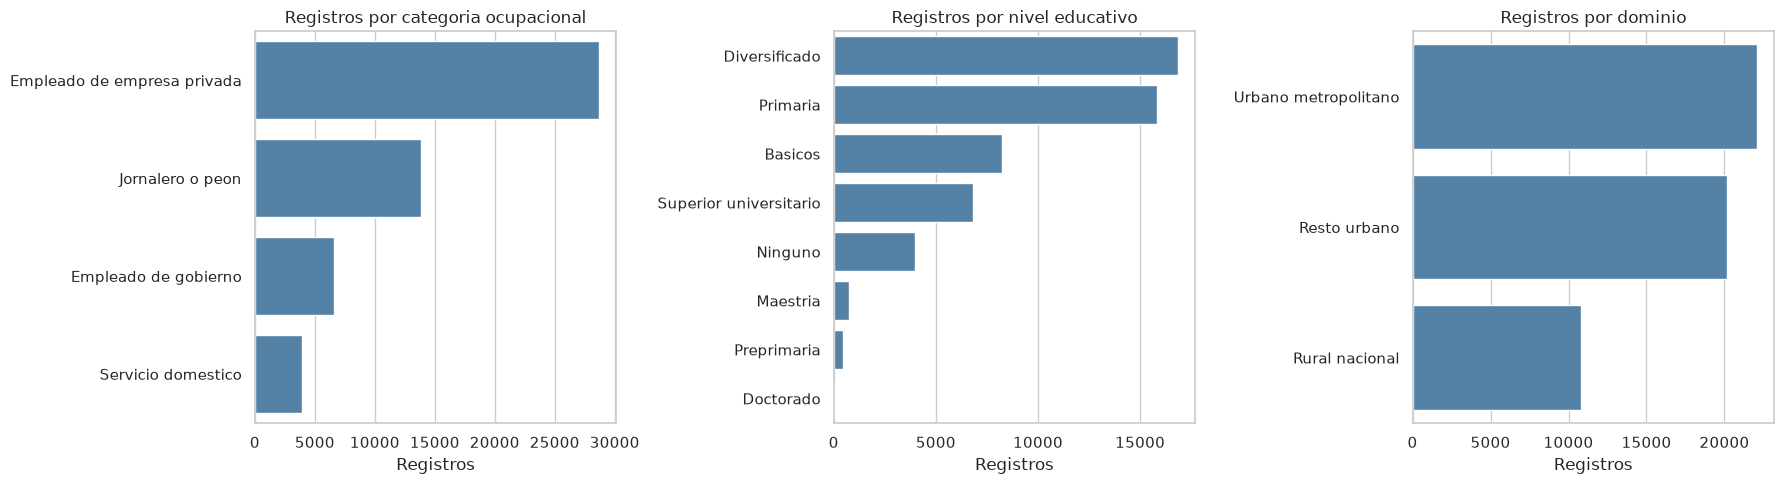

--- categoria_ocupacional ---
      categoria_ocupacional  count   pct
Empleado de empresa privada  28702 54.13
           Jornalero o peon  13842 26.10
       Empleado de gobierno   6575 12.40
         Servicio domestico   3906  7.37 

--- nivel_educativo ---
       nivel_educativo  count   pct
         Diversificado  16851 31.78
              Primaria  15822 29.84
               Basicos   8249 15.56
Superior universitario   6818 12.86
               Ninguno   3995  7.53
              Maestria    771  1.45
           Preprimaria    459  0.87
             Doctorado     60  0.11 

--- dominio ---
             dominio  count   pct
Urbano metropolitano  22072 41.63
        Resto urbano  20146 37.99
      Rural nacional  10807 20.38 



In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def conteo_categoria(df, columna):
    return (df.groupBy(columna).count()
            .orderBy(f.desc("count"))
            .toPandas())   # tabla agregada, no filas crudas

conteos = {c: conteo_categoria(analitico_2025, c)
           for c in ["categoria_ocupacional", "nivel_educativo", "dominio"]}

fig, ejes = plt.subplots(1, 3, figsize=(18, 5))
for eje, (columna, tabla) in zip(ejes, conteos.items()):
    sns.barplot(data=tabla, y=columna, x="count", ax=eje, color="steelblue")
    eje.set_title(f"Registros por {columna.replace('_', ' ')}")
    eje.set_xlabel("Registros")
    eje.set_ylabel("")
plt.tight_layout()
plt.show()

for columna, tabla in conteos.items():
    tabla["pct"] = (100 * tabla["count"] / tabla["count"].sum()).round(2)
    print(f"--- {columna} ---")
    print(tabla.to_string(index=False), "\n")

### 2.3. Forma de la distribución del salario

Registros en la muestra grafica: 5192


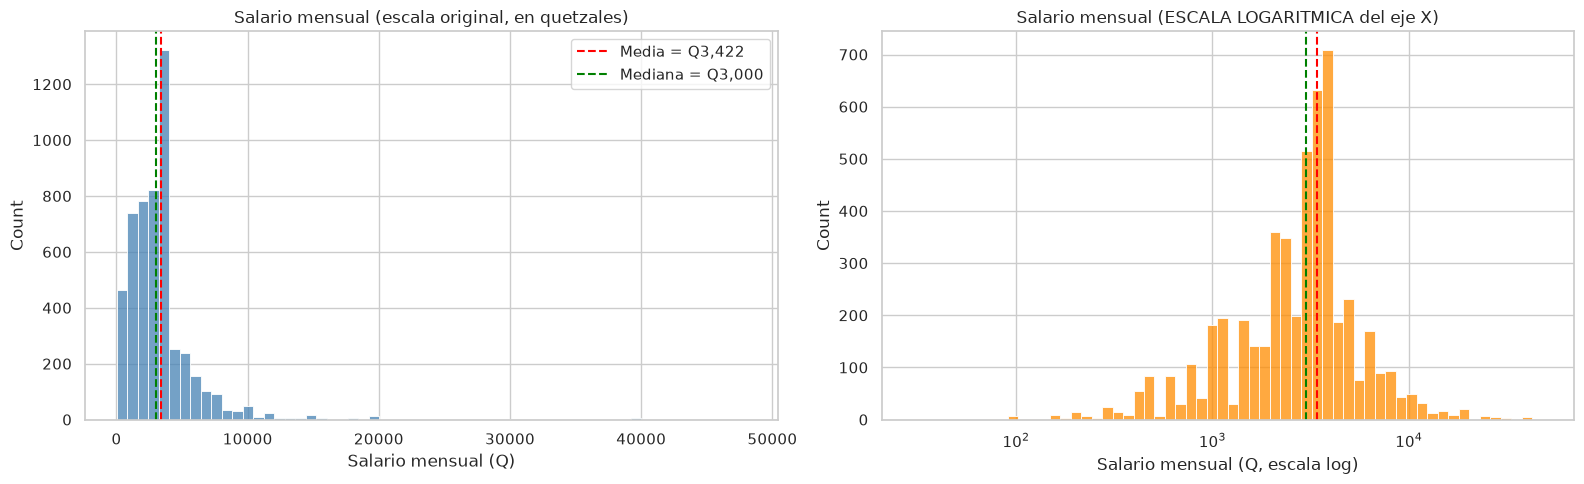

Media / mediana = 1.14
NOTA: la escala log es solo para visualizar. El modelado usa el salario en quetzales.


In [15]:
# Muestra SOLO para dibujar (las metricas ya se calcularon sobre el total)
muestra_salario = (
    analitico_2025.select("salario_mensual")
    .sample(withReplacement=False, fraction=0.10, seed=SEED)
    .limit(10000)
    .toPandas()
)
print("Registros en la muestra grafica:", len(muestra_salario))

media = float(resumen_2025.loc["salario_mensual", "media"])
mediana = float(resumen_2025.loc["salario_mensual", "mediana"])

fig, ejes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data=muestra_salario, x="salario_mensual", bins=60, color="steelblue", ax=ejes[0])
ejes[0].axvline(media, color="red", linestyle="--", label=f"Media = Q{media:,.0f}")
ejes[0].axvline(mediana, color="green", linestyle="--", label=f"Mediana = Q{mediana:,.0f}")
ejes[0].set_title("Salario mensual (escala original, en quetzales)")
ejes[0].set_xlabel("Salario mensual (Q)")
ejes[0].legend()

sns.histplot(data=muestra_salario, x="salario_mensual", bins=60, log_scale=True,
             color="darkorange", ax=ejes[1])
ejes[1].axvline(media, color="red", linestyle="--")
ejes[1].axvline(mediana, color="green", linestyle="--")
ejes[1].set_title("Salario mensual (ESCALA LOGARITMICA del eje X)")
ejes[1].set_xlabel("Salario mensual (Q, escala log)")

plt.tight_layout()
plt.show()

print(f"Media / mediana = {media / mediana:.2f}")
print("NOTA: la escala log es solo para visualizar. El modelado usa el salario en quetzales.")

> **¿El salario presenta una distribución simétrica o asimétrica? ¿Qué diferencia existe entre su
> media y su mediana?**
>
> La distribución es **asimétrica a la derecha**, aunque menos extrema de lo que podría esperarse:
> la razón media/mediana es de **1.14** (Q3,421.68 contra Q3,000). La asimetría se ve mejor en el
> rango que en esa razón: el máximo (Q99,000) está a más de doce veces el percentil 95 (Q8,000).
>
> En la escala original se distingue un **pico muy marcado alrededor de Q3,000**, que corresponde a
> la zona del salario mínimo, y una cola larga y delgada hacia la derecha que se extiende hasta
> valores atípicamente altos. En escala logarítmica la distribución se vuelve mucho más simétrica,
> lo cual indica que el salario se comporta aproximadamente como una **log-normal**. También se
> notan acumulaciones en valores redondos (1,000, 2,000, 3,000, 5,000), típicas del redondeo al
> reportar ingresos en una encuesta.
>
> La media supera a la mediana porque unos pocos salarios muy altos la jalan hacia arriba, mientras
> que la mediana no se ve afectada por los extremos. Para describir al asalariado típico, la
> **mediana es la medida adecuada**; la media sirve para hablar de la masa salarial total. Esto
> anticipa un problema para la regresión lineal de la actividad 5: al minimizar el error cuadrático,
> los salarios altos pesan desproporcionadamente.
>
> *(La escala logarítmica se usa solo para visualizar; el modelado conserva el salario en quetzales,
> como pide el enunciado.)*

### 2.4. Salario mediano por nivel educativo y por categoría ocupacional

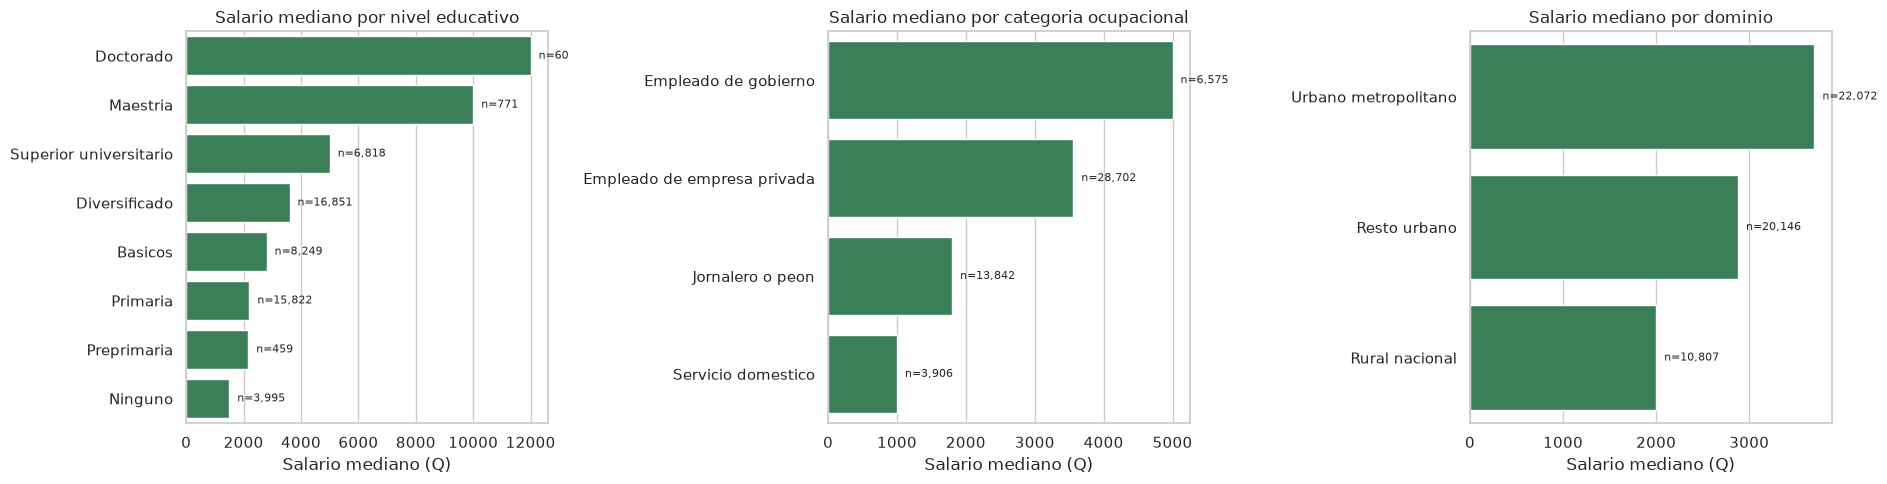

,nivel_educativo,salario_mediano,n
0,Doctorado,12000.0,60
1,Maestria,10000.0,771
2,Superior universitario,5000.0,6818
3,Diversificado,3600.0,16851
4,Basicos,2800.0,8249
5,Primaria,2200.0,15822
6,Preprimaria,2160.0,459
7,Ninguno,1500.0,3995


,categoria_ocupacional,salario_mediano,n
0,Empleado de gobierno,5000.0,6575
1,Empleado de empresa privada,3560.0,28702
2,Jornalero o peon,1800.0,13842
3,Servicio domestico,1000.0,3906


,dominio,salario_mediano,n
0,Urbano metropolitano,3700.0,22072
1,Resto urbano,2880.0,20146
2,Rural nacional,2000.0,10807


In [16]:
def mediana_por_grupo(df, columna):
    return (df.groupBy(columna)
            .agg(f.expr("percentile_approx(salario_mensual, 0.5, 10000)").alias("salario_mediano"),
                 f.count("*").alias("n"))
            .orderBy(f.desc("salario_mediano"))
            .toPandas())

med_educ = mediana_por_grupo(analitico_2025, "nivel_educativo")
med_cat  = mediana_por_grupo(analitico_2025, "categoria_ocupacional")
med_dom  = mediana_por_grupo(analitico_2025, "dominio")

fig, ejes = plt.subplots(1, 3, figsize=(19, 5))
for eje, (titulo, tabla, columna) in zip(ejes, [
    ("Nivel educativo", med_educ, "nivel_educativo"),
    ("Categoria ocupacional", med_cat, "categoria_ocupacional"),
    ("Dominio", med_dom, "dominio"),
]):
    sns.barplot(data=tabla, y=columna, x="salario_mediano", ax=eje, color="seagreen")
    eje.set_title(f"Salario mediano por {titulo.lower()}")
    eje.set_xlabel("Salario mediano (Q)")
    eje.set_ylabel("")
    for i, fila in tabla.reset_index(drop=True).iterrows():
        eje.text(fila["salario_mediano"], i, f"  n={fila['n']:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

display(med_educ, med_cat, med_dom)

> **¿Cómo varía el salario mediano entre niveles educativos y categorías ocupacionales?**
>
> **Por nivel educativo** la relación es **monótona creciente, sin una sola excepción**:
>
> | Nivel | Salario mediano | n |
> |---|---|---|
> | Doctorado | Q12,000 | 60 |
> | Maestría | Q10,000 | 771 |
> | Superior universitario | Q5,000 | 6,818 |
> | Diversificado | Q3,600 | 16,851 |
> | Básicos | Q2,800 | 8,249 |
> | Primaria | Q2,200 | 15,822 |
> | Preprimaria | Q2,160 | 459 |
> | Ninguno | Q1,500 | 3,995 |
>
> El retorno a la educación es claramente **no lineal**: pasar de primaria a básicos agrega unos
> Q600, pero pasar de diversificado a superior agrega Q1,400, y de superior a maestría otros
> Q5,000. Quien tiene título universitario gana la mediana **3.3 veces** lo que gana quien no tiene
> ningún nivel educativo. Ojo con los grupos pequeños: doctorado tiene apenas 60 registros y
> preprimaria 459, así que esas medianas son mucho menos estables que las de primaria o
> diversificado. El hecho de que el orden sea perfectamente monótono también sirve como
> **validación indirecta de las etiquetas asignadas a los códigos** en la sección 0.3.
>
> **Por categoría ocupacional** el orden es: **gobierno (Q5,000) > empresa privada (Q3,560) >
> jornalero o peón (Q1,800) > servicio doméstico (Q1,000)**. El empleo público paga la mediana más
> alta, pero eso no significa necesariamente que pague mejor a igualdad de perfil: su composición
> es distinta (concentra más puestos que exigen educación superior). Justamente eso es lo que la
> regresión de la actividad 5 permitirá separar, al controlar por nivel educativo. En el extremo
> opuesto, el servicio doméstico tiene una mediana de Q1,000, muy por debajo del salario mínimo.
>
> **Por dominio** también hay un gradiente claro: urbano metropolitano (Q3,700), resto urbano
> (Q2,880) y rural nacional (Q2,000). El área metropolitana paga casi el doble que el área rural.
>
> Todas estas son **asociaciones descriptivas**, no efectos causales.

### 2.5. Evolución entre trimestres

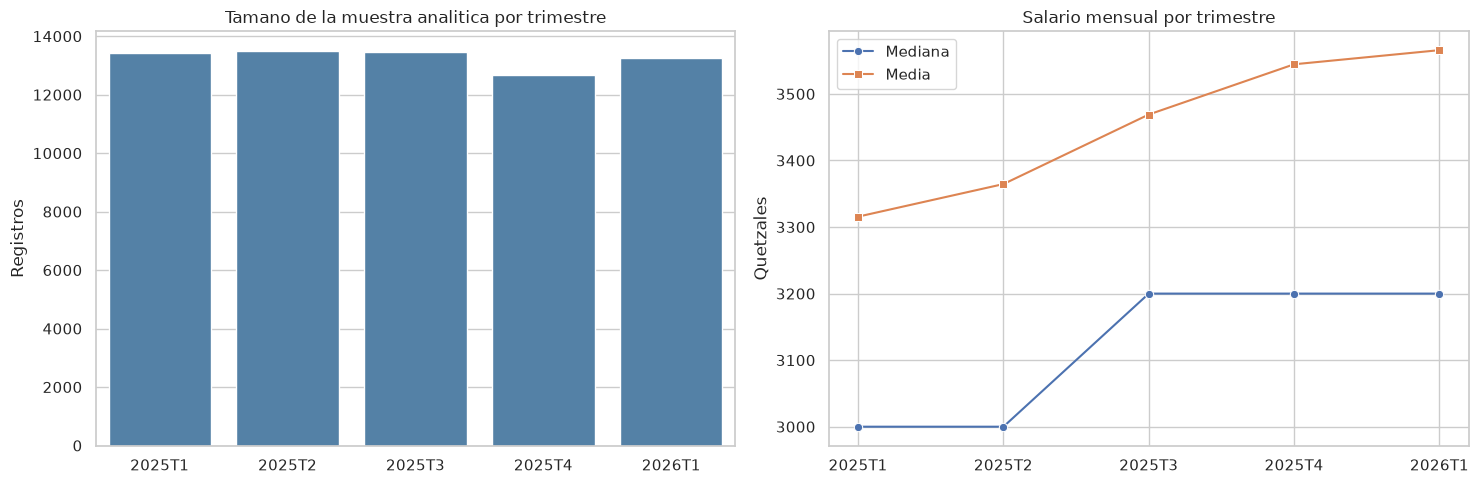

,periodo_archivo,n_registros,salario_mediano,salario_medio
0,2025T1,13419,3000.0,3315.63
1,2025T2,13492,3000.0,3364.57
2,2025T3,13450,3200.0,3469.07
3,2025T4,12664,3200.0,3544.57
4,2026T1,13258,3200.0,3565.80


In [17]:
por_trimestre = (
    analitico_2025.unionByName(analitico_2026)
    .groupBy("periodo_archivo")
    .agg(f.count("*").alias("n_registros"),
         f.expr("percentile_approx(salario_mensual, 0.5, 10000)").alias("salario_mediano"),
         f.mean("salario_mensual").alias("salario_medio"))
    .orderBy("periodo_archivo")
    .toPandas()
)

fig, ejes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=por_trimestre, x="periodo_archivo", y="n_registros", ax=ejes[0], color="steelblue")
ejes[0].set_title("Tamano de la muestra analitica por trimestre")
ejes[0].set_xlabel("")
ejes[0].set_ylabel("Registros")

sns.lineplot(data=por_trimestre, x="periodo_archivo", y="salario_mediano", marker="o",
             ax=ejes[1], label="Mediana")
sns.lineplot(data=por_trimestre, x="periodo_archivo", y="salario_medio", marker="s",
             ax=ejes[1], label="Media")
ejes[1].set_title("Salario mensual por trimestre")
ejes[1].set_xlabel("")
ejes[1].set_ylabel("Quetzales")
plt.tight_layout()
plt.show()

por_trimestre.round(2)

> **¿Cómo cambian el tamaño de la muestra analítica y el salario mediano entre trimestres?**
>
> | Período | Registros | Salario mediano | Salario medio |
> |---|---|---|---|
> | 2025T1 | 13,419 | Q3,000 | Q3,315.63 |
> | 2025T2 | 13,492 | Q3,000 | Q3,364.57 |
> | 2025T3 | 13,450 | Q3,200 | Q3,469.07 |
> | 2025T4 | 12,664 | Q3,200 | Q3,544.57 |
> | 2026T1 | 13,258 | Q3,200 | Q3,565.80 |
>
> El tamaño de la muestra analítica es **muy estable**: oscila entre 12,664 y 13,492 registros, una
> variación de apenas 6 % entre el trimestre más alto y el más bajo. El porcentaje retenido tras los
> filtros también es casi idéntico en los cinco archivos (entre 25.7 % y 26.6 %), lo que indica que
> las reglas de preparación se comportan de forma consistente en todos los períodos y que no hay un
> archivo anómalo.
>
> El **salario mediano sube un escalón** entre el segundo y el tercer trimestre de 2025, de Q3,000 a
> Q3,200, y se mantiene ahí. Ese salto discreto sugiere un efecto de agrupamiento alrededor del
> salario mínimo más que un crecimiento gradual. La **media**, en cambio, crece de forma sostenida
> en los cinco períodos (de Q3,315.63 a Q3,565.80, un 7.5 % acumulado), porque es sensible a los
> salarios altos de la cola.
>
> Dos advertencias: son **cifras nominales sin ajuste por inflación**, así que el aumento no implica
> mayor poder adquisitivo; y por el diseño rotativo, buena parte de las personas se repite entre
> trimestres, de modo que estas series **no son muestras independientes**.

---
## 3. Relaciones entre variables numéricas (5 pts)

Se usa `Correlation.corr()` de `pyspark.ml.stat` sobre **todos** los registros elegibles de 2025.

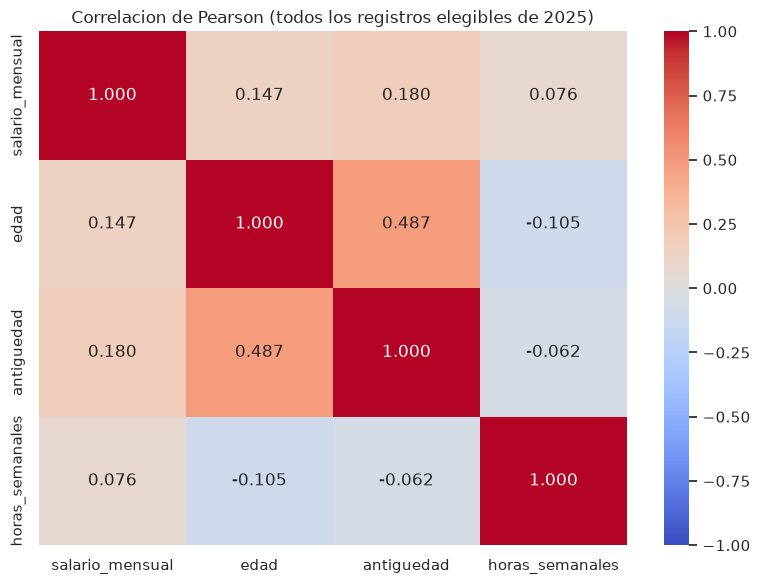

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


In [18]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

ensamblador_corr = VectorAssembler(inputCols=VARIABLES_NUM, outputCol="vars_num")
datos_corr = ensamblador_corr.transform(analitico_2025).select("vars_num")

matriz = Correlation.corr(datos_corr, "vars_num", method="pearson").head()[0]
matriz_corr = pd.DataFrame(matriz.toArray(), index=VARIABLES_NUM, columns=VARIABLES_NUM)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlacion de Pearson (todos los registros elegibles de 2025)")
plt.tight_layout()
plt.show()

matriz_corr.round(3)

> **¿Qué variables presentan mayor asociación lineal con el salario? ¿Existe relación entre edad y
> antigüedad?**
>
> | | salario | edad | antigüedad | horas |
> |---|---|---|---|---|
> | **salario** | 1.000 | 0.147 | 0.180 | 0.076 |
> | **edad** | 0.147 | 1.000 | 0.487 | -0.105 |
> | **antigüedad** | 0.180 | 0.487 | 1.000 | -0.062 |
> | **horas** | 0.076 | -0.105 | -0.062 | 1.000 |
>
> **Con el salario, las tres correlaciones son positivas pero muy débiles.** La mayor es la de
> **antigüedad (0.180)**, seguida de **edad (0.147)** y, en último lugar, **horas semanales
> (0.076)**, que es prácticamente nula. Este último resultado es contraintuitivo (uno esperaría que
> trabajar más horas implicara ganar más) y tiene varias explicaciones: la mayoría de asalariados se
> concentra en jornadas cercanas a las 45 horas, así que la variable casi no varía en el grueso de
> los datos; y quienes trabajan jornadas extremas suelen estar en ocupaciones de baja remuneración,
> lo cual cancela el efecto esperado.
>
> Hay dos razones de fondo para que todas sean tan bajas. Primero, la correlación de Pearson mide
> asociación **lineal**, y el salario tiene una distribución asimétrica con valores extremos que
> debilitan el coeficiente. Segundo, y más importante, **los determinantes fuertes del salario en
> estos datos son categóricos**: la sección 2.4 mostró que el salario mediano se multiplica por 3.3
> entre niveles educativos y por 5 entre categorías ocupacionales, y nada de eso aparece en esta
> matriz. La implicación directa para la actividad 5 es que un modelo con solo las tres variables
> numéricas tendría un R² muy bajo; el poder predictivo vendrá de las variables codificadas con
> `OneHotEncoder`.
>
> **Entre edad y antigüedad sí hay una relación clara: 0.487**, la correlación más alta de la
> matriz. Es lógico, porque no se puede acumular más antigüedad que años de vida (de hecho es uno de
> los filtros de consistencia). Pero está lejos de 1, lo cual confirma lo que ya mostraba la
> estadística descriptiva: mucha gente mayor lleva poco tiempo en su empleo actual, señal de alta
> rotación. Es una **colinealidad moderada** que conviene recordar al interpretar los coeficientes
> de la regresión: ambas variables comparten información, así que sus coeficientes individuales
> pueden ser inestables.
>
> Por último, edad y horas tienen una correlación **negativa** (-0.105): los trabajadores mayores
> tienden a jornadas algo más cortas.

---
## 4. Segmentación de perfiles mediante KMeans (10 pts)

### 4.1. ¿Conviene incluir el salario en el clustering?

Se prueban **dos configuraciones** para decidirlo con evidencia:
- **A (sin salario):** `edad`, `antiguedad`, `horas_semanales`. Segmenta perfiles por
  características personales y laborales, y permite luego **comparar el salario entre clústeres**
  como variable externa.
- **B (con salario):** agrega `salario_mensual`. Al ser una variable muy asimétrica, tiende a
  dominar la distancia euclidiana y los clústeres terminan siendo básicamente tramos de salario.

Todas las variables se estandarizan con `StandardScaler`, porque KMeans usa distancia euclidiana y
sin escalar la variable con mayor rango (el salario, en miles) dominaría por completo.

In [19]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

VARS_CLUSTER_A = ["edad", "antiguedad", "horas_semanales"]
VARS_CLUSTER_B = VARS_CLUSTER_A + ["salario_mensual"]

def pipeline_kmeans(variables, k, seed=SEED):
    return Pipeline(stages=[
        VectorAssembler(inputCols=variables, outputCol="vars_crudas"),
        StandardScaler(inputCol="vars_crudas", outputCol="features", withMean=True, withStd=True),
        KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=seed, maxIter=50),
    ])

evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster",
                                metricName="silhouette", distanceMeasure="squaredEuclidean")

def evaluar_k(variables, etiqueta, ks=(2, 3, 4, 5)):
    filas = []
    for k in ks:
        modelo = pipeline_kmeans(variables, k).fit(analitico_2025)
        asignado = modelo.transform(analitico_2025)
        filas.append({
            "configuracion": etiqueta,
            "k": k,
            "silhouette": evaluador.evaluate(asignado),
            "wssse": modelo.stages[-1].summary.trainingCost,
        })
        print(f"{etiqueta} | k={k} -> silhouette={filas[-1]['silhouette']:.4f} | WSSSE={filas[-1]['wssse']:,.0f}")
    return filas

resultados_k = evaluar_k(VARS_CLUSTER_A, "A (sin salario)") + evaluar_k(VARS_CLUSTER_B, "B (con salario)")
tabla_k = pd.DataFrame(resultados_k)
tabla_k.round(4)

A (sin salario) | k=2 -> silhouette=0.5545 | WSSSE=106,717
A (sin salario) | k=3 -> silhouette=0.4429 | WSSSE=84,468
A (sin salario) | k=4 -> silhouette=0.4760 | WSSSE=64,438
A (sin salario) | k=5 -> silhouette=0.4839 | WSSSE=54,990
B (con salario) | k=2 -> silhouette=0.5148 | WSSSE=157,346
B (con salario) | k=3 -> silhouette=0.3372 | WSSSE=133,003
B (con salario) | k=4 -> silhouette=0.3753 | WSSSE=113,688
B (con salario) | k=5 -> silhouette=0.4137 | WSSSE=94,476


,configuracion,k,silhouette,wssse
0,A (sin salario),2,0.5545,106717.3880
1,A (sin salario),3,0.4429,84468.1462
2,A (sin salario),4,0.4760,64438.2080
3,A (sin salario),5,0.4839,54990.3529
4,B (con salario),2,0.5148,157345.5589
5,B (con salario),3,0.3372,133003.1572
6,B (con salario),4,0.3753,113688.2060
7,B (con salario),5,0.4137,94475.7167


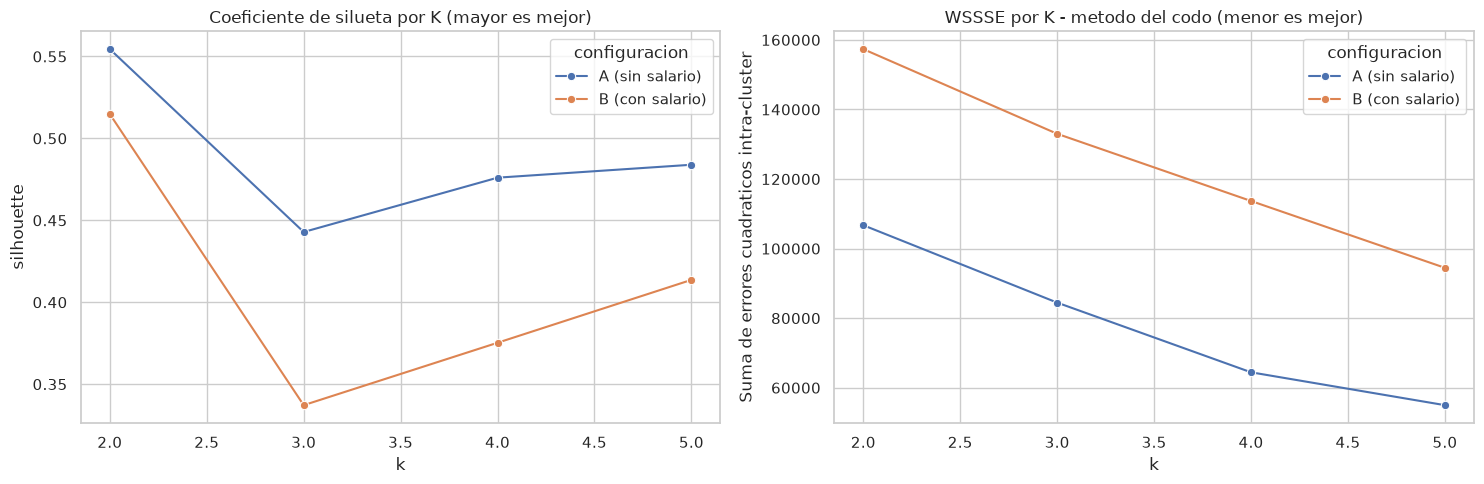

In [20]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=tabla_k, x="k", y="silhouette", hue="configuracion", marker="o", ax=ejes[0])
ejes[0].set_title("Coeficiente de silueta por K (mayor es mejor)")
sns.lineplot(data=tabla_k, x="k", y="wssse", hue="configuracion", marker="o", ax=ejes[1])
ejes[1].set_title("WSSSE por K - metodo del codo (menor es mejor)")
ejes[1].set_ylabel("Suma de errores cuadraticos intra-cluster")
plt.tight_layout()
plt.show()

> **Decisión del equipo:**
>
> **Variables: se elige la configuración A (sin salario).** La evidencia lo respalda: la
> configuración A obtiene **mejor silueta que la B en los cuatro valores de K probados** (0.5545
> contra 0.5148 en K=2; 0.4760 contra 0.3753 en K=4). Agregar el salario **empeora** la calidad de
> los clústeres, lo cual tiene sentido porque es una variable muy asimétrica y con valores extremos
> que distorsionan los centroides de KMeans, que se basan en la media.
>
> A esto se suman dos razones metodológicas: el objetivo de la actividad es identificar **perfiles
> de trabajadores** según edad, antigüedad y jornada, no tramos salariales; y dejar el salario fuera
> permite usarlo después como **variable de validación externa** (si los perfiles construidos sin
> salario muestran salarios distintos, es un hallazgo real y no una tautología).
>
> **Número de clústeres: K = 4.** Aquí los dos criterios no coinciden y la decisión es un
> compromiso explícito:
> - La **silueta** es máxima en **K=2** (0.5545) y luego cae en K=3 (0.4429) para volver a subir en
>   K=4 (0.4760) y K=5 (0.4839).
> - El **WSSSE** baja de forma sostenida (106,717 → 84,468 → 64,438 → 54,990) **sin un codo
>   marcado**.
>
> Que la silueta sea máxima en K=2 y que el codo no exista indica que los datos **no tienen
> fronteras naturales bien separadas**: los perfiles son un resumen útil de un continuo, no grupos
> realmente aislados. Con K=2 la partición sería demasiado gruesa para describir perfiles
> laborales interpretables, y K=5 apenas mejora la silueta sobre K=4 (0.4839 contra 0.4760) a costa
> de un grupo más. Por eso el grupo elige **K=4**, que da la mejor combinación entre calidad
> métrica e interpretabilidad, como se ve en la caracterización de la siguiente sección.

### 4.2. Modelo final y descripción de los perfiles

In [21]:
K_ELEGIDO = 4          # <-- ajustar segun la tabla y las graficas anteriores
VARS_FINAL = VARS_CLUSTER_A

modelo_cluster = pipeline_kmeans(VARS_FINAL, K_ELEGIDO).fit(analitico_2025)
clusterizado = modelo_cluster.transform(analitico_2025).persist()

perfil = (
    clusterizado.groupBy("cluster")
    .agg(
        f.count("*").alias("n"),
        f.mean("edad").alias("edad_media"),
        f.mean("antiguedad").alias("antiguedad_media"),
        f.mean("horas_semanales").alias("horas_medias"),
        f.expr("percentile_approx(salario_mensual, 0.5, 10000)").alias("salario_mediano"),
        f.mean("salario_mensual").alias("salario_medio"),
    )
    .orderBy("cluster")
    .toPandas()
)
perfil["pct"] = (100 * perfil["n"] / perfil["n"].sum()).round(2)
perfil.round(2)

,cluster,n,edad_media,antiguedad_media,horas_medias,salario_mediano,salario_medio,pct
0,0,8928,30.55,3.48,74.76,3000.0,3240.87,16.84
1,1,24488,25.82,2.42,40.95,3000.0,3074.74,46.18
2,2,12742,48.52,4.06,39.50,3000.0,3536.70,24.03
3,3,6867,49.90,22.24,41.06,3800.0,4680.57,12.95


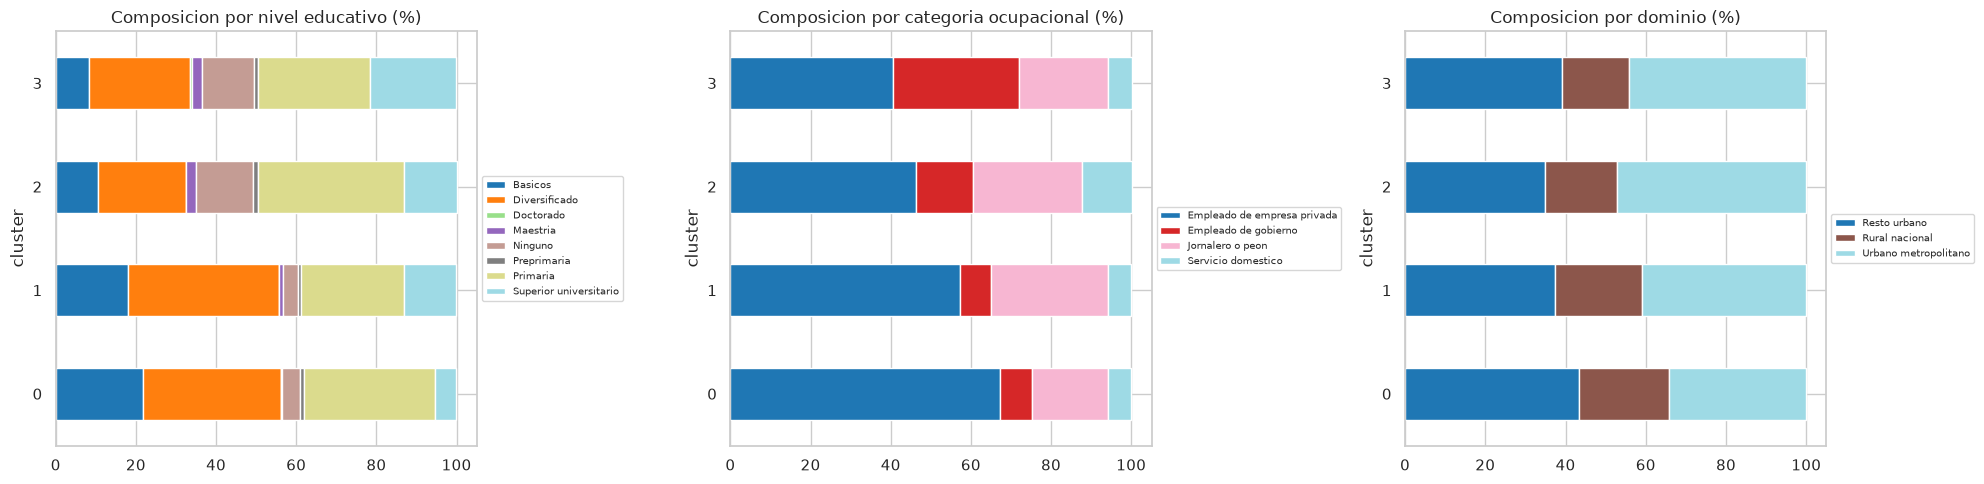

,cluster,categoria_ocupacional,count,n_cluster,pct
0,0,Empleado de empresa privada,6011,8928,67.3
1,0,Jornalero o peon,1686,8928,18.9
2,0,Empleado de gobierno,711,8928,8.0
3,0,Servicio domestico,520,8928,5.8
4,1,Empleado de empresa privada,14007,24488,57.2
5,1,Jornalero o peon,7150,24488,29.2
6,1,Empleado de gobierno,1912,24488,7.8
7,1,Servicio domestico,1419,24488,5.8
8,2,Empleado de empresa privada,5906,12742,46.4
9,2,Jornalero o peon,3475,12742,27.3


,cluster,dominio,count,n_cluster,pct
0,0,Resto urbano,3865,8928,43.3
1,0,Urbano metropolitano,3047,8928,34.1
2,0,Rural nacional,2016,8928,22.6
3,1,Urbano metropolitano,10007,24488,40.9
4,1,Resto urbano,9137,24488,37.3
5,1,Rural nacional,5344,24488,21.8
6,2,Urbano metropolitano,5993,12742,47.0
7,2,Resto urbano,4450,12742,34.9
8,2,Rural nacional,2299,12742,18.0
9,3,Urbano metropolitano,3025,6867,44.1


In [22]:
# Composicion categorica de cada cluster (para describirlos)
def composicion(columna):
    total = clusterizado.groupBy("cluster").count().withColumnRenamed("count", "n_cluster")
    return (clusterizado.groupBy("cluster", columna).count()
            .join(total, on="cluster")
            .withColumn("pct", f.round(100 * f.col("count") / f.col("n_cluster"), 1))
            .orderBy("cluster", f.desc("pct"))
            .toPandas())

comp_educ = composicion("nivel_educativo")
comp_cat  = composicion("categoria_ocupacional")
comp_dom  = composicion("dominio")

fig, ejes = plt.subplots(1, 3, figsize=(20, 5))
for eje, (titulo, tabla, columna) in zip(ejes, [
    ("nivel educativo", comp_educ, "nivel_educativo"),
    ("categoria ocupacional", comp_cat, "categoria_ocupacional"),
    ("dominio", comp_dom, "dominio"),
]):
    tabla_pivote = tabla.pivot(index="cluster", columns=columna, values="pct").fillna(0)
    tabla_pivote.plot(kind="barh", stacked=True, ax=eje, colormap="tab20")
    eje.set_title(f"Composicion por {titulo} (%)")
    eje.legend(fontsize=7, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

display(comp_cat, comp_dom)

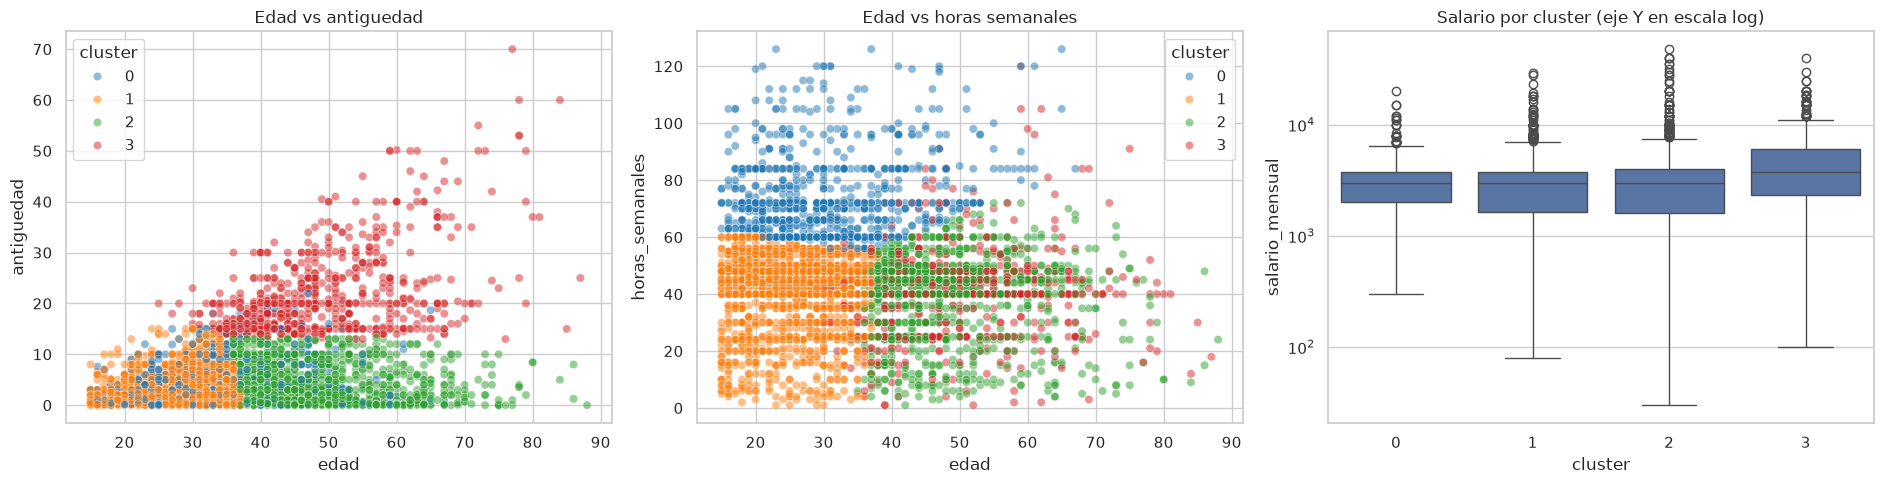

In [23]:
# Visualizacion de los clusters (muestra de hasta 5,000 registros solo para dibujar)
muestra_cluster = (
    clusterizado
    .select("edad", "antiguedad", "horas_semanales", "salario_mensual", "cluster")
    .sample(withReplacement=False, fraction=0.10, seed=SEED)
    .limit(5000)
    .toPandas()
)

fig, ejes = plt.subplots(1, 3, figsize=(19, 5))
sns.scatterplot(data=muestra_cluster, x="edad", y="antiguedad", hue="cluster",
                palette="tab10", alpha=0.5, ax=ejes[0])
ejes[0].set_title("Edad vs antiguedad")
sns.scatterplot(data=muestra_cluster, x="edad", y="horas_semanales", hue="cluster",
                palette="tab10", alpha=0.5, ax=ejes[1])
ejes[1].set_title("Edad vs horas semanales")
sns.boxplot(data=muestra_cluster, x="cluster", y="salario_mensual", ax=ejes[2])
ejes[2].set_yscale("log")
ejes[2].set_title("Salario por cluster (eje Y en escala log)")
plt.tight_layout()
plt.show()

### 4.3. Descripción de los perfiles encontrados

Con K=4 y las variables edad, antigüedad y horas semanales estandarizadas, los perfiles quedaron
así:

| Clúster | n | % | Edad media | Antigüedad media | Horas medias | Salario mediano | Salario medio |
|---|---|---|---|---|---|---|---|
| 0 | 8,928 | 16.8 % | 30.6 | 3.5 | **74.8** | Q3,000 | Q3,240.87 |
| 1 | 24,488 | 46.2 % | 25.8 | 2.4 | 41.0 | Q3,000 | Q3,074.74 |
| 2 | 12,742 | 24.0 % | 48.5 | 4.1 | 39.5 | Q3,000 | Q3,536.70 |
| 3 | 6,867 | 13.0 % | 49.9 | **22.2** | 41.1 | **Q3,800** | Q4,680.57 |

**Descripción de cada perfil:**

- **Clúster 0 — Jornada extrema (16.8 %).** Se define por una sola característica dominante: un
  promedio de **74.8 horas semanales**, más del doble de lo normal y muy por encima de la jornada
  legal. Son personas jóvenes (30.6 años) con poca antigüedad (3.5 años). Es el grupo con mayor
  proporción de empleo privado (67.3 %). Pese a trabajar casi el doble de horas que el resto, su
  salario mediano es **idéntico** al de los demás grupos (Q3,000), lo cual es el hallazgo más
  llamativo de toda la segmentación.
- **Clúster 1 — Jóvenes en jornada estándar (46.2 %).** El grupo más numeroso, casi la mitad de la
  muestra. Son los más jóvenes (25.8 años), con la menor antigüedad (2.4 años) y jornada normal
  (41 horas). Concentra la mayor proporción de jornaleros o peones (29.2 %) y tiene el salario medio
  más bajo (Q3,074.74). Representa la puerta de entrada al mercado laboral asalariado.
- **Clúster 2 — Trabajadores maduros con baja antigüedad (24.0 %).** Edad alta (48.5 años) pero
  apenas 4.1 años en su empleo actual. Es la evidencia más directa de la **alta rotación** del
  mercado laboral: gente con muchos años de vida laboral que ha cambiado de empleo recientemente.
  Es también el grupo con mayor proporción de servicio doméstico (12.3 %).
- **Clúster 3 — Veteranos consolidados (13.0 %).** Edad similar al clúster 2 (49.9 años) pero con
  **22.2 años de antigüedad promedio**: son quienes construyeron una carrera en un mismo empleo. Es
  el grupo con mayor presencia de empleo público (31.4 %, contra 8 % en el clúster 0) y el único que
  se despega en salario: mediana de Q3,800 y media de Q4,680.57, un 52 % más que el clúster 1.

**Lecturas principales:**

1. La variable que más separa a los grupos es la **jornada** (que aísla al clúster 0) seguida de la
   combinación **edad–antigüedad** (que separa los clústeres 1, 2 y 3).
2. Como el salario **no** se usó para construir los clústeres, las diferencias salariales que
   aparecen entre ellos son un resultado, no un artefacto. Pero el hallazgo es que esas diferencias
   son **pequeñas**: tres de los cuatro grupos tienen exactamente la misma mediana (Q3,000) y solo
   los veteranos consolidados se despegan. Esto es totalmente coherente con las correlaciones
   débiles de la sección 3: edad, antigüedad y horas **explican poco del salario**, y lo que sí lo
   explica (educación y categoría ocupacional) quedó fuera del clustering.
3. Trabajar 75 horas semanales no se traduce en una mediana salarial más alta, lo cual sugiere que
   las jornadas extendidas se concentran en ocupaciones con baja remuneración por hora.

**Advertencias metodológicas:**
- Los clústeres son un **resumen descriptivo**, no categorías naturales: la silueta moderada y la
  ausencia de codo indican que los grupos se tocan entre sí.
- KMeans asume grupos de forma esférica y tamaño similar, y usa la media, que es sensible a valores
  extremos.
- La etiqueta de clúster **no se usará como predictor** en las actividades 5 a 8, tal como indica el
  enunciado.

---


In [24]:
# Liberamos la cache antes de continuar con las secciones 5-8
for df in [crudo_2025, crudo_2026, clusterizado]:
    df.unpersist()
print("Listo.")

Listo.
